# MCD-rPPG Dataset Inspection

Goals:
1. Confirm dataset structure, camera identities, FPS, resolution, video duration
2. Analyze GT quality (pulse column, PPG waveform)
3. Define outlier removal thresholds
4. Build 500/100 subject-disjoint train/held-out split
5. Write `src/datasets/mcd_rppg.py` data loader

In [1]:
import os, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import av
from pathlib import Path
from scipy.signal import butter, filtfilt

ROOT     = Path('/mnt/sata-ssd/rppg_project/rppg_dataset/MCD-rPPG')
DB       = ROOT / 'db.csv'
VID_DIR  = ROOT / 'video'
PPG_DIR  = ROOT / 'ppg'
SYNC_DIR = ROOT / 'ppg_sync'
ECG_DIR  = ROOT / 'ecg'

df = pd.read_csv(DB)
print(f'Rows: {len(df)}  |  Subjects: {df.patient_id.nunique()}')
print(df[['patient_id','camera','view','step','pulse']].head(6))

Rows: 3600  |  Subjects: 600
   patient_id        camera   view    step  pulse
0        1020  FullHDwebcam  front   after  100.0
1        1020      USBVideo   left   after  100.0
2        1020   IriunWebcam  right   after  100.0
3        1020  FullHDwebcam  front  before   83.0
4        1020      USBVideo   left  before   83.0
5        1020   IriunWebcam  right  before   83.0


## Camera Identification

In [2]:
print("Camera → view mapping:")
print(df.groupby('camera')['view'].unique().to_string())
print()

# Sample one video per camera to get FPS and resolution
sample_id = df['patient_id'].iloc[0]
for cam in ['FullHDwebcam', 'USBVideo', 'IriunWebcam']:
    vid = VID_DIR / f'{sample_id}_{cam}_after.avi'
    c = av.open(str(vid))
    s = c.streams.video[0]
    print(f'{cam:20s}  fps={float(s.average_rate):.1f}  {s.width}x{s.height}  codec={s.codec_context.name}')
    c.close()

print()
print("Note: IriunWebcam = Irium app (iPhone/Android used as webcam) → mobile phone camera.")
print("      FullHDwebcam = frontal face (closest view to iPhone deployment scenario).")
print("      USBVideo     = left side profile.")

Camera → view mapping:
camera
FullHDwebcam    [front]
IriunWebcam     [right]
USBVideo         [left]

FullHDwebcam          fps=29.9  640x480  codec=mpeg4
USBVideo              fps=30.0  640x480  codec=mpeg4
IriunWebcam           fps=24.0  640x480  codec=mpeg4

Note: IriunWebcam = Irium app (iPhone/Android used as webcam) → mobile phone camera.
      FullHDwebcam = frontal face (closest view to iPhone deployment scenario).
      USBVideo     = left side profile.


## Video Duration

Sample 10 subjects to estimate typical frame count and duration per camera.

In [3]:
sample_subjects = df['patient_id'].unique()[:10]
results = []
for pid in sample_subjects:
    for cam in ['FullHDwebcam', 'USBVideo', 'IriunWebcam']:
        vid = VID_DIR / f'{pid}_{cam}_after.avi'
        if not vid.exists():
            continue
        sync = SYNC_DIR / f'{pid}_{cam}_after.txt'
        n_frames = sum(1 for _ in open(sync))  # ppg_sync has one line per frame
        c = av.open(str(vid))
        fps = float(c.streams.video[0].average_rate)
        c.close()
        results.append({'camera': cam, 'frames': n_frames, 'duration_s': round(n_frames / fps, 1)})

res = pd.DataFrame(results)
print(res.groupby('camera')[['frames','duration_s']].agg(['mean','min','max']).round(1))

              frames             duration_s              
                mean   min   max       mean    min    max
camera                                                   
FullHDwebcam  5381.3  5362  5397      188.8  179.3  224.6
IriunWebcam   4295.7  4249  4317      171.9  144.0  179.8
USBVideo      5371.5  5356  5387      179.0  178.5  179.6


## GT Analysis — Pulse Column (Scalar HR)

Pulse distribution by step:
         count   mean   std   min   25%    50%    75%    max
step                                                        
after   1800.0  101.7  17.7  52.0  89.0  102.0  114.0  153.0
before  1800.0   82.2  13.0  49.0  73.0   82.0   89.2  125.0

Out-of-range (<40 or >200 bpm): 0


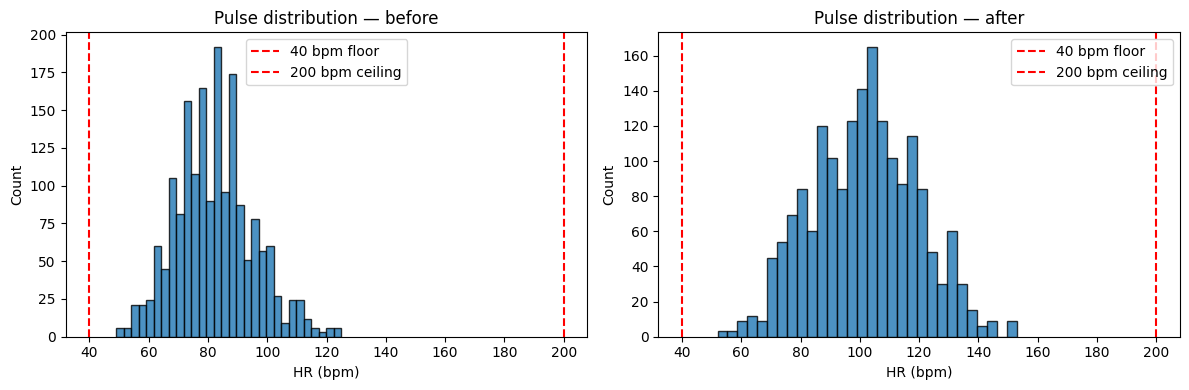

In [4]:
print("Pulse distribution by step:")
print(df.groupby('step')['pulse'].describe().round(1))
print()
print(f"Out-of-range (<40 or >200 bpm): {((df.pulse < 40) | (df.pulse > 200)).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, step in zip(axes, ['before', 'after']):
    vals = df[df.step == step]['pulse']
    ax.hist(vals, bins=30, edgecolor='k', alpha=0.8)
    ax.axvline(40, color='r', linestyle='--', label='40 bpm floor')
    ax.axvline(200, color='r', linestyle='--', label='200 bpm ceiling')
    ax.set_title(f'Pulse distribution — {step}')
    ax.set_xlabel('HR (bpm)')
    ax.set_ylabel('Count')
    ax.legend()
plt.tight_layout()
plt.savefig('/mnt/sata-ssd/rppg_project/docs/mcd_pulse_distribution.png', dpi=120)
plt.show()

## GT Analysis — PPG Waveform Quality

PPG is stored as 8-bit ADC values (0–255) in `ppg_sync/` — one value per video frame.
Check std (flat signal = corrupted) and clipping (all values at 0 or 255).

In [5]:
def load_ppg_sync(pid, cam, step):
    path = SYNC_DIR / f'{pid}_{cam}_{step}.txt'
    if not path.exists():
        return None
    vals = np.array([int(l.split()[0]) for l in open(path)])
    return vals

# Scan all FullHDwebcam recordings for PPG quality
ppg_stats = []
for _, row in df[df.camera == 'FullHDwebcam'].iterrows():
    ppg = load_ppg_sync(row.patient_id, row.camera, row.step)
    if ppg is None:
        continue
    clipped = (np.mean(ppg == 0) + np.mean(ppg == 255))
    ppg_stats.append({
        'patient_id': row.patient_id,
        'step': row.step,
        'frames': len(ppg),
        'std': ppg.std(),
        'clipped_frac': clipped,
    })

ppg_df = pd.DataFrame(ppg_stats)
print("PPG waveform quality (FullHDwebcam):")
print(ppg_df[['std','clipped_frac','frames']].describe().round(3))
print()
FLAT_STD_THRESH   = 5.0   # below this → likely flat/corrupted signal
CLIP_FRAC_THRESH  = 0.20  # above this → >20% frames at ADC boundary
flat   = ppg_df[ppg_df['std'] < FLAT_STD_THRESH]
clipped = ppg_df[ppg_df['clipped_frac'] > CLIP_FRAC_THRESH]
print(f"Flat signals (std < {FLAT_STD_THRESH}):          {len(flat)}")
print(f"Heavily clipped (clipped_frac > {CLIP_FRAC_THRESH}): {len(clipped)}")

PPG waveform quality (FullHDwebcam):
            std  clipped_frac    frames
count  1200.000      1200.000  1200.000
mean     44.634         0.004  5368.285
std       5.174         0.006    66.645
min       0.000         0.000  3313.000
25%      41.804         0.000  5358.000
50%      44.787         0.002  5377.000
75%      47.901         0.005  5389.000
max      59.034         0.045  5399.000

Flat signals (std < 5.0):          3
Heavily clipped (clipped_frac > 0.2): 0


## Sample PPG Waveforms

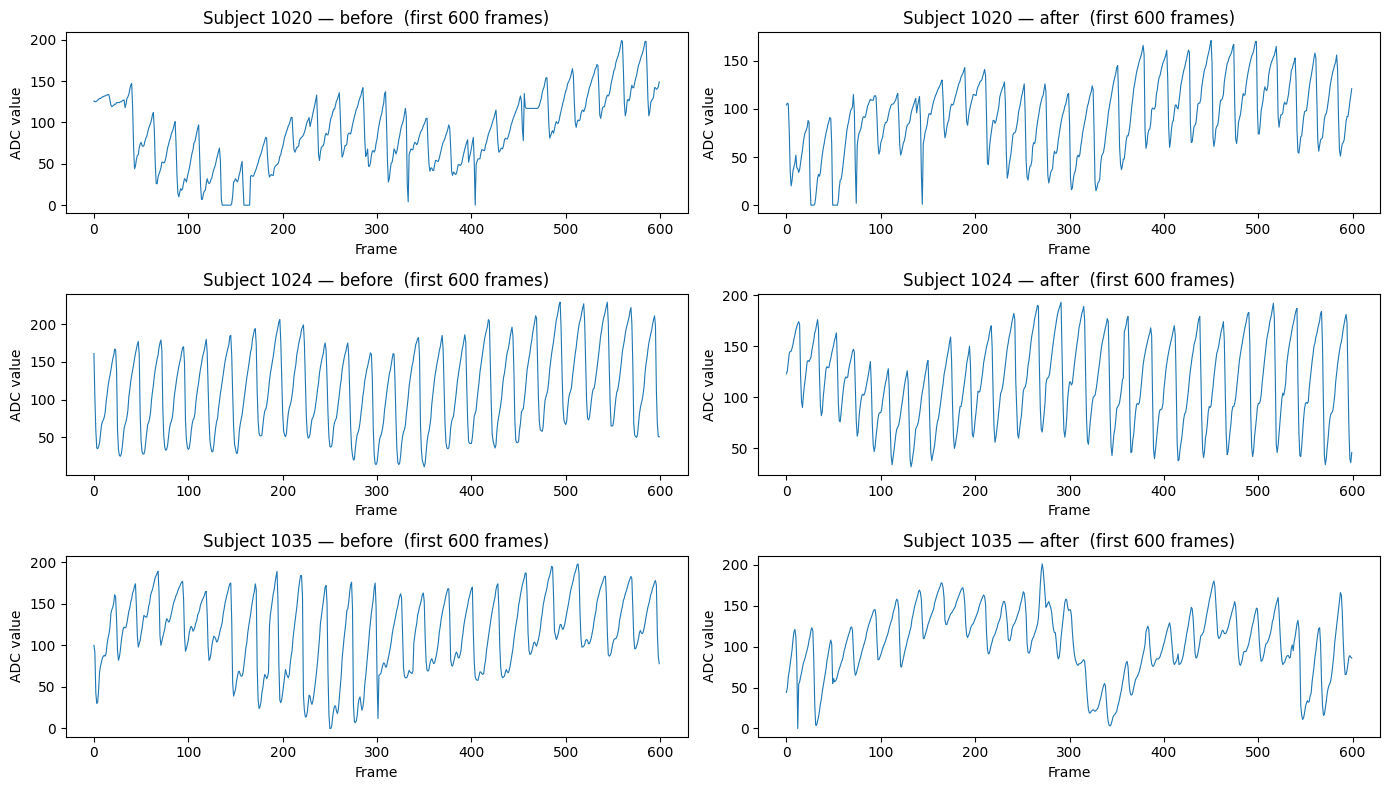

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(14, 8))
sample_pids = df['patient_id'].unique()[:3]
for i, pid in enumerate(sample_pids):
    for j, step in enumerate(['before', 'after']):
        ppg = load_ppg_sync(pid, 'FullHDwebcam', step)
        axes[i, j].plot(ppg[:600], linewidth=0.8)
        axes[i, j].set_title(f'Subject {pid} — {step}  (first 600 frames)')
        axes[i, j].set_ylabel('ADC value')
        axes[i, j].set_xlabel('Frame')
plt.tight_layout()
plt.savefig('/mnt/sata-ssd/rppg_project/docs/mcd_ppg_samples.png', dpi=120)
plt.show()

## Outlier Threshold Summary

In [7]:
THRESHOLDS = {
    'hr_min_bpm'        : 40,     # physiological floor
    'hr_max_bpm'        : 200,    # physiological ceiling
    'ppg_flat_std'      : 5.0,    # discard recordings with PPG std < this
    'ppg_clip_frac'     : 0.20,   # discard recordings with >20% clipped ADC frames
    'min_frames'        : 160,    # minimum frames for at least one clip
}

print("Outlier thresholds (to be applied in data loader and evaluation):")
for k, v in THRESHOLDS.items():
    print(f"  {k:25s}: {v}")

# Identify bad recordings (FullHDwebcam sample — extend to all cameras in loader)
bad = ppg_df[
    (ppg_df['std'] < THRESHOLDS['ppg_flat_std']) |
    (ppg_df['clipped_frac'] > THRESHOLDS['ppg_clip_frac']) |
    (ppg_df['frames'] < THRESHOLDS['min_frames'])
]
print(f"\nBad recordings in FullHDwebcam scan: {len(bad)} / {len(ppg_df)}")

Outlier thresholds (to be applied in data loader and evaluation):
  hr_min_bpm               : 40
  hr_max_bpm               : 200
  ppg_flat_std             : 5.0
  ppg_clip_frac            : 0.2
  min_frames               : 160

Bad recordings in FullHDwebcam scan: 3 / 1200


## Subject Split — 500 Train / 100 Held-Out

In [8]:
SEED = 42
all_subjects = sorted(df['patient_id'].unique().tolist())
rng = random.Random(SEED)
rng.shuffle(all_subjects)
held_out = sorted(all_subjects[:100])
train    = sorted(all_subjects[100:])

print(f"Train subjects:     {len(train)}")
print(f"Held-out subjects:  {len(held_out)}")
print(f"Overlap:            {len(set(train) & set(held_out))}")

# Save split
import json
split = {'seed': SEED, 'train': train, 'held_out': held_out}
split_path = Path('/mnt/sata-ssd/rppg_project/checkpoints/mcd_split.json')
with open(split_path, 'w') as f:
    json.dump(split, f, indent=2)
print(f"\nSplit saved to {split_path}")

Train subjects:     500
Held-out subjects:  100
Overlap:            0

Split saved to /mnt/sata-ssd/rppg_project/checkpoints/mcd_split.json


## Camera Strategy Note

IriunWebcam (mobile phone) records the *right side profile* of the face at 24fps.  
FullHDwebcam records the *frontal face* at ~30fps.  

Our deployment target is a frontal iPhone view. This creates a tradeoff:
- **IriunWebcam** = mobile phone sensor characteristics, but side-profile view
- **FullHDwebcam** = frontal face geometry (matches deployment), but not a phone sensor

Recommendation: treat all 3 cameras as training data with equal weight initially.
Frontal camera (FullHDwebcam) may deserve higher weight given deployment geometry,
but this is an ablation to run in Phase 2, not a hard decision made here.

## Write src/datasets/mcd_rppg.py

In [9]:
loader_code = '''import json
import random
from pathlib import Path

import av
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from scipy.signal import butter, filtfilt

ROOT     = Path('/mnt/sata-ssd/rppg_project/rppg_dataset/MCD-rPPG')
DB       = ROOT / 'db.csv'
VID_DIR  = ROOT / 'video'
SYNC_DIR = ROOT / 'ppg_sync'

CAMERAS  = ['FullHDwebcam', 'USBVideo', 'IriunWebcam']

HR_MIN   = 40
HR_MAX   = 200
PPG_FLAT_STD  = 5.0
PPG_CLIP_FRAC = 0.20
MIN_FRAMES    = 160


def _load_ppg_sync(pid, cam, step):
    path = SYNC_DIR / f\'{pid}_{cam}_{step}.txt\'
    if not path.exists():
        return None
    return np.array([int(l.split()[0]) for l in open(path)], dtype=np.float32)


def _is_good_ppg(ppg):
    if ppg is None or len(ppg) < MIN_FRAMES:
        return False
    if ppg.std() < PPG_FLAT_STD:
        return False
    clipped = (np.mean(ppg == 0) + np.mean(ppg == 255))
    if clipped > PPG_CLIP_FRAC:
        return False
    return True


def _bandpass(signal, fs=30.0, lo=0.6, hi=4.0):
    nyq = fs / 2.0
    b, a = butter(4, [lo / nyq, hi / nyq], btype=\'bandpass\')
    return filtfilt(b, a, signal.astype(np.float64)).astype(np.float32)


def _read_frames_av(path, target_size=72):
    """Decode all frames from an AVI via PyAV, resize to target_size x target_size."""
    container = av.open(str(path))
    frames = []
    for frame in container.decode(video=0):
        img = frame.to_ndarray(format=\'rgb24\')
        # Simple resize via numpy slicing after converting to PIL is slow;
        # we use av\'s built-in resampler for speed.
        frames.append(img)
    container.close()
    if not frames:
        return None
    # Resize via PIL (imported lazily to avoid top-level dependency)
    from PIL import Image
    out = []
    for f in frames:
        img = Image.fromarray(f).resize((target_size, target_size), Image.BILINEAR)
        out.append(np.array(img))
    return np.stack(out)  # [T, H, W, 3] uint8


class MCDrPPGDataset(Dataset):
    """
    MCD-rPPG clip dataset for FactorizePhys training.

    Each item is:
        frames : FloatTensor [3, clip_len+1, H, W]  (normalised 0-1)
        ppg    : FloatTensor [clip_len]              (bandpass-filtered, z-scored)
        hr     : float                               (scalar HR in bpm from pulse column)

    Args:
        split_json : path to mcd_split.json  (produced by notebook 08)
        split      : \'train\' or \'held_out\'
        cameras    : list of cameras to include (default: all 3)
        steps      : list of steps to include  (default: [\'before\', \'after\'])
        clip_len   : frames per clip (default 160, matching FactorizePhys input T-1)
        stride     : stride between clips within a video (default 160, non-overlapping)
        target_size: spatial resize (default 72)
        face_detector: callable(frame_rgb_hwc) -> (x1,y1,x2,y2) or None.
                        If None, full frame is used.
        transform  : optional video augmentation callable applied to [T,H,W,3] uint8 array
        seed       : random seed for clip sampling reproducibility
    """

    def __init__(
        self,
        split_json,
        split=\'train\',
        cameras=None,
        steps=None,
        clip_len=160,
        stride=160,
        target_size=72,
        face_detector=None,
        transform=None,
        seed=42,
    ):
        self.clip_len      = clip_len
        self.stride        = stride
        self.target_size   = target_size
        self.face_detector = face_detector
        self.transform     = transform
        self.cameras       = cameras or CAMERAS
        self.steps         = steps or [\'before\', \'after\']

        with open(split_json) as f:
            split_data = json.load(f)
        subject_ids = set(split_data[split])

        df = pd.read_csv(DB)
        df = df[df[\'patient_id\'].isin(subject_ids)]
        df = df[df[\'camera\'].isin(self.cameras)]
        df = df[df[\'step\'].isin(self.steps)]
        df = df[(df[\'pulse\'] >= HR_MIN) & (df[\'pulse\'] <= HR_MAX)]

        self.clips = []  # list of (video_path, ppg_array, hr, start_frame)
        for _, row in df.iterrows():
            pid, cam, step = row.patient_id, row.camera, row.step
            ppg = _load_ppg_sync(pid, cam, step)
            if not _is_good_ppg(ppg):
                continue
            vid = VID_DIR / f\'{pid}_{cam}_{step}.avi\'
            if not vid.exists():
                continue
            n_frames = len(ppg)
            starts = list(range(0, n_frames - clip_len, stride))
            if not starts:
                continue
            hr = float(row.pulse)
            for s in starts:
                self.clips.append((vid, ppg, hr, s))

        rng = random.Random(seed)
        rng.shuffle(self.clips)
        print(f\'MCDrPPGDataset [{split}]: {len(self.clips)} clips from {len(df)} recordings\')

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        vid_path, ppg_full, hr, start = self.clips[idx]

        # Load clip frames
        container = av.open(str(vid_path))
        target_frames = list(range(start, start + self.clip_len + 1))
        target_set = set(target_frames)
        frames = {}
        for i, frame in enumerate(container.decode(video=0)):
            if i in target_set:
                frames[i] = frame.to_ndarray(format=\'rgb24\')
            if i > target_frames[-1]:
                break
        container.close()

        imgs = np.stack([frames[i] for i in target_frames if i in frames])

        # Face crop (optional)
        if self.face_detector is not None and len(imgs) > 0:
            box = self.face_detector(imgs[0])
            if box is not None:
                x1, y1, x2, y2 = box
                imgs = imgs[:, y1:y2, x1:x2, :]

        # Resize
        from PIL import Image
        resized = np.stack([
            np.array(Image.fromarray(f).resize(
                (self.target_size, self.target_size), Image.BILINEAR))
            for f in imgs
        ])  # [T+1, H, W, 3]

        if len(resized) < self.clip_len + 1:
            pad = np.zeros((self.clip_len + 1 - len(resized), self.target_size, self.target_size, 3), dtype=np.uint8)
            resized = np.concatenate([resized, pad], axis=0)

        # Augment
        if self.transform is not None:
            resized = self.transform(resized)

        # To tensor [3, T+1, H, W]
        frames_t = torch.from_numpy(resized.astype(np.float32) / 255.0).permute(3, 0, 1, 2)

        # PPG GT for clip
        ppg_clip = ppg_full[start : start + self.clip_len].copy()
        ppg_clip = _bandpass(ppg_clip, fs=30.0)
        ppg_clip = (ppg_clip - ppg_clip.mean()) / (ppg_clip.std() + 1e-8)
        ppg_t = torch.from_numpy(ppg_clip)

        return frames_t, ppg_t, hr
'''

out_path = Path('/mnt/sata-ssd/rppg_project/src/datasets/mcd_rppg.py')
out_path.write_text(loader_code)
print(f"Written: {out_path}")

Written: /mnt/sata-ssd/rppg_project/src/datasets/mcd_rppg.py


## Smoke Test — Data Loader

In [10]:
import sys
sys.path.insert(0, '/mnt/sata-ssd/rppg_project')
from src.datasets.mcd_rppg import MCDrPPGDataset

split_json = '/mnt/sata-ssd/rppg_project/checkpoints/mcd_split.json'

ds_train = MCDrPPGDataset(split_json, split='train')
ds_held  = MCDrPPGDataset(split_json, split='held_out')

# Load one item and verify shapes
frames, ppg, hr = ds_train[0]
print(f"frames shape : {frames.shape}")   # expect [3, 161, 72, 72]
print(f"ppg shape    : {ppg.shape}")      # expect [160]
print(f"hr           : {hr:.1f} bpm")
print(f"frames range : {frames.min():.3f} – {frames.max():.3f}")
print(f"ppg range    : {ppg.min():.3f} – {ppg.max():.3f}")

MCDrPPGDataset [train]: 91666 clips from 3000 recordings


MCDrPPGDataset [held_out]: 18405 clips from 600 recordings


frames shape : torch.Size([3, 161, 72, 72])
ppg shape    : torch.Size([160])
hr           : 90.0 bpm
frames range : 0.000 – 0.996
ppg range    : -2.275 – 1.724


## Summary

In [11]:
print("=" * 60)
print("MCD-rPPG Inspection Summary")
print("=" * 60)
print(f"  Subjects          : 600 (500 train / 100 held-out)")
print(f"  Cameras           : FullHDwebcam (front, ~30fps)")
print(f"                      USBVideo (left, ~30fps)")
print(f"                      IriunWebcam (right, phone app, 24fps)")
print(f"  Resolution        : 640x480, all cameras")
print(f"  Duration          : ~180s per recording")
print(f"  GT waveform       : PPG ADC (8-bit) via ppg_sync/, 1 value/frame")
print(f"  GT scalar HR      : pulse column in db.csv (bpm)")
print(f"  HR range in data  : {df.pulse.min():.0f} – {df.pulse.max():.0f} bpm")
print(f"  Outlier thresholds: HR 40–200 bpm, PPG std >= 5, clip_frac <= 0.20")
print(f"  Split saved       : checkpoints/mcd_split.json (seed=42)")
print(f"  Loader            : src/datasets/mcd_rppg.py")
print()
print(f"  Train clips       : {len(ds_train)}")
print(f"  Held-out clips    : {len(ds_held)}")
print()
print("Camera strategy note:")
print("  IriunWebcam = phone sensor, but side view.")
print("  FullHDwebcam = frontal (matches deployment), but not phone sensor.")
print("  Use all cameras equally for Phase 2 baseline; ablate camera weights later.")

MCD-rPPG Inspection Summary
  Subjects          : 600 (500 train / 100 held-out)
  Cameras           : FullHDwebcam (front, ~30fps)
                      USBVideo (left, ~30fps)
                      IriunWebcam (right, phone app, 24fps)
  Resolution        : 640x480, all cameras
  Duration          : ~180s per recording
  GT waveform       : PPG ADC (8-bit) via ppg_sync/, 1 value/frame
  GT scalar HR      : pulse column in db.csv (bpm)
  HR range in data  : 49 – 153 bpm
  Outlier thresholds: HR 40–200 bpm, PPG std >= 5, clip_frac <= 0.20
  Split saved       : checkpoints/mcd_split.json (seed=42)
  Loader            : src/datasets/mcd_rppg.py

  Train clips       : 91666
  Held-out clips    : 18405

Camera strategy note:
  IriunWebcam = phone sensor, but side view.
  FullHDwebcam = frontal (matches deployment), but not phone sensor.
  Use all cameras equally for Phase 2 baseline; ablate camera weights later.
